In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')


## Dataset: Monthly Airline Passengers (1949–1960)\nClassic benchmark for ARIMA — has both trend and seasonality. 144 monthly observations.

In [2]:
# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, header=0, index_col=0, parse_dates=True)
df.columns = ['passengers']
df.index.freq = 'MS'  # month start frequency

print(df.shape)
df.head()


(144, 1)


,passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


## Step 1: Visualize the Series

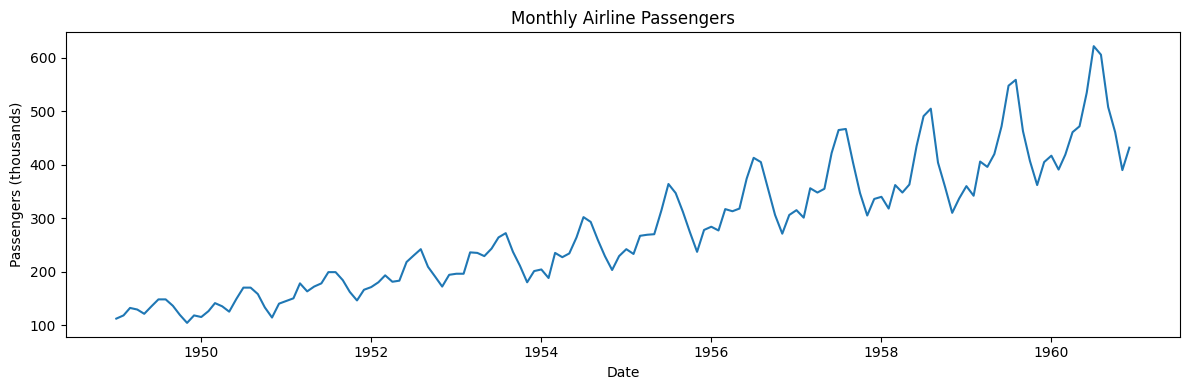

In [3]:
plt.figure(figsize=(12, 4))
plt.plot(df['passengers'])
plt.title('Monthly Airline Passengers')
plt.ylabel('Passengers (thousands)')
plt.xlabel('Date')
plt.tight_layout()
plt.show()


## Step 2: Check Stationarity (ADF Test)\nNull hypothesis: series has a unit root (non-stationary). p-value < 0.05 → reject → stationary.

In [4]:
def adf_test(series, label=""):
    result = adfuller(series.dropna())
    print(f"ADF Test — {label}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  Stationary    : {result[1] < 0.05}\n")

adf_test(df['passengers'], "Original series")


ADF Test — Original series
  ADF Statistic : 0.8154
  p-value       : 0.9919
  Stationary    : False



## Step 3: Differencing (find d)\nApply log transform first to stabilize variance, then difference.

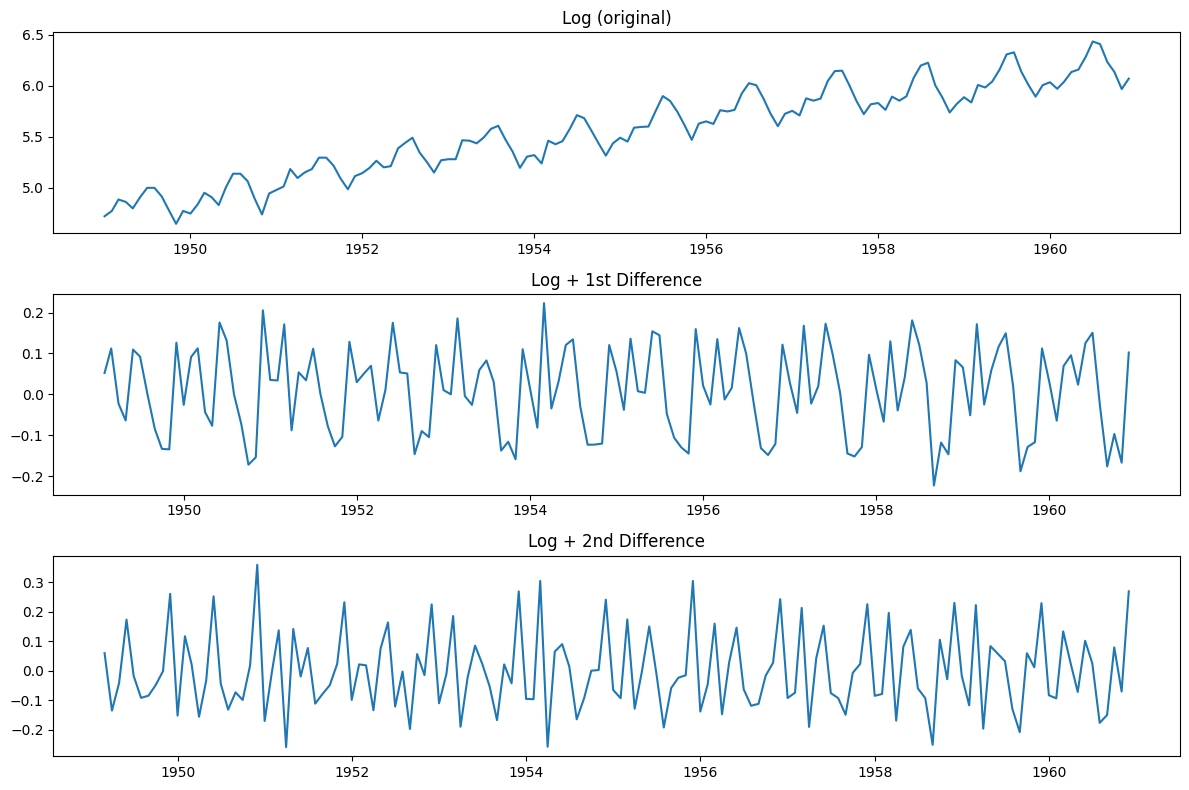

ADF Test — After 1st difference
  ADF Statistic : -2.7171
  p-value       : 0.0711
  Stationary    : False

ADF Test — After 2nd difference
  ADF Statistic : -8.1966
  p-value       : 0.0000
  Stationary    : True



In [5]:
df['log_passengers'] = np.log(df['passengers'])
df['diff1'] = df['log_passengers'].diff()
df['diff2'] = df['diff1'].diff()

fig, axes = plt.subplots(3, 1, figsize=(12, 8))
axes[0].plot(df['log_passengers']); axes[0].set_title('Log (original)')
axes[1].plot(df['diff1']); axes[1].set_title('Log + 1st Difference')
axes[2].plot(df['diff2']); axes[2].set_title('Log + 2nd Difference')
plt.tight_layout()
plt.show()

adf_test(df['diff1'], "After 1st difference")
adf_test(df['diff2'], "After 2nd difference")


## Step 4: ACF and PACF Plots (find p and q)

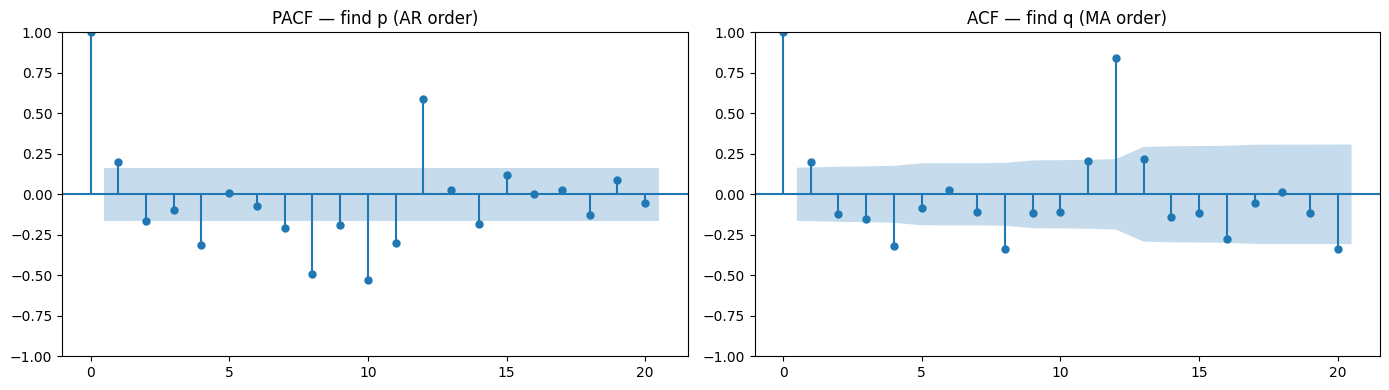

In [6]:
stationary_series = df['diff1'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_pacf(stationary_series, lags=20, ax=axes[0], title='PACF — find p (AR order)')
plot_acf(stationary_series, lags=20, ax=axes[1], title='ACF — find q (MA order)')
plt.tight_layout()
plt.show()


## Step 5: Fit ARIMA Model\nTrain on 80% of data, test on remaining 20%.

In [7]:
series = df['log_passengers']
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

print(f"Train: {len(train)} samples | Test: {len(test)} samples")

# Fit ARIMA — p, d, q chosen from ACF/PACF inspection
model = ARIMA(train, order=(2, 1, 2))
result = model.fit()
print(result.summary())


Train: 115 samples | Test: 29 samples
                               SARIMAX Results                                
Dep. Variable:         log_passengers   No. Observations:                  115
Model:                 ARIMA(2, 1, 2)   Log Likelihood                 104.653
Date:                Wed, 15 Apr 2026   AIC                           -199.305
Time:                        23:58:25   BIC                           -185.624
Sample:                    01-01-1949   HQIC                          -193.753
                         - 07-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2460      0.187      1.313      0.189      -0.121       0.613
ar.L2          0.2594      0.241      1.076      0.282      -0.213       0.732
ma.L1         

## Step 6: Forecast and Evaluate

RMSE: 82.86 thousand passengers


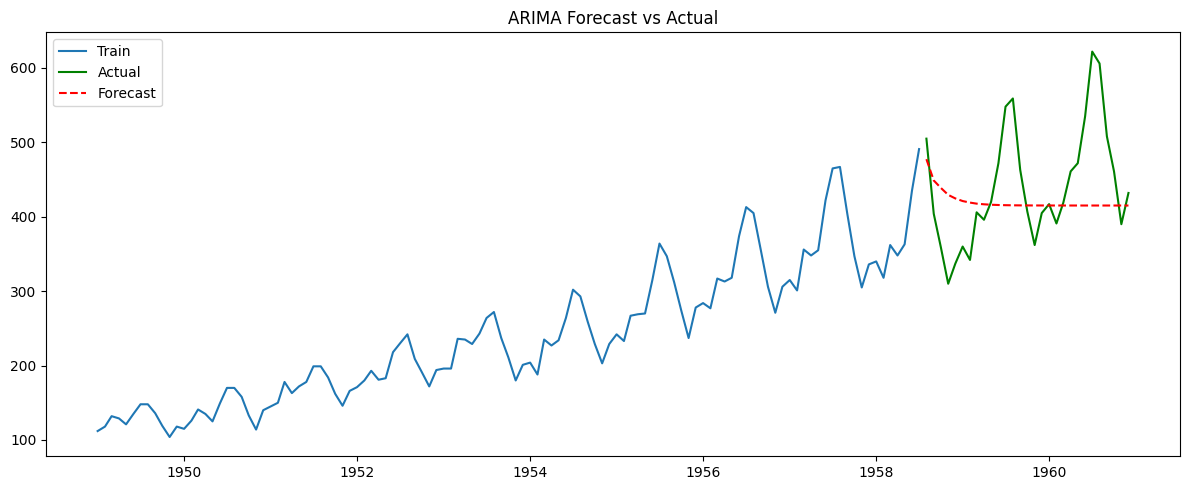

In [8]:
forecast = result.forecast(steps=len(test))

# Convert back from log scale
forecast_actual = np.exp(forecast)
test_actual = np.exp(test)

rmse = np.sqrt(mean_squared_error(test_actual, forecast_actual))
print(f"RMSE: {rmse:.2f} thousand passengers")

plt.figure(figsize=(12, 5))
plt.plot(np.exp(train), label='Train')
plt.plot(test_actual, label='Actual', color='green')
plt.plot(forecast_actual, label='Forecast', color='red', linestyle='--')
plt.title('ARIMA Forecast vs Actual')
plt.legend()
plt.tight_layout()
plt.show()


## Step 7: Residual Analysis\nResiduals should be white noise — no autocorrelation remaining.

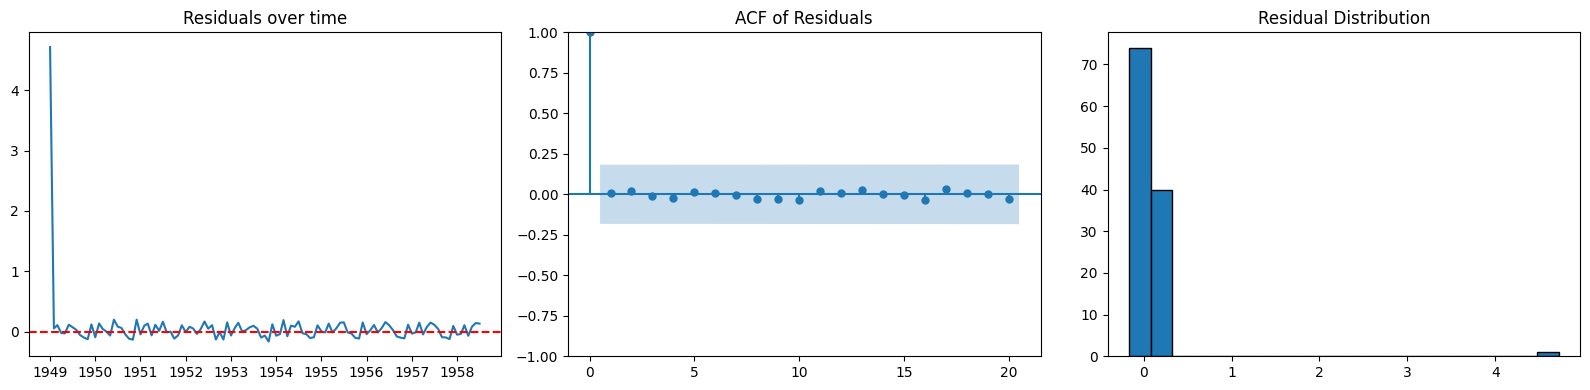

ADF Test — Residuals
  ADF Statistic : -3.2396
  p-value       : 0.0178
  Stationary    : True



In [9]:
residuals = result.resid

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(residuals)
axes[0].set_title('Residuals over time')
axes[0].axhline(0, color='red', linestyle='--')

plot_acf(residuals, lags=20, ax=axes[1], title='ACF of Residuals')

axes[2].hist(residuals, bins=20, edgecolor='black')
axes[2].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

adf_test(residuals, "Residuals")


---
## ARIMA on Seasonality-Free Data: Shampoo Sales

The airline dataset has strong seasonal spikes at lag 12 in ACF — ARIMA cannot model these.  
The **shampoo sales** dataset (monthly, 3 years) has a clear upward trend but **no seasonality**, making it a clean ARIMA use case.

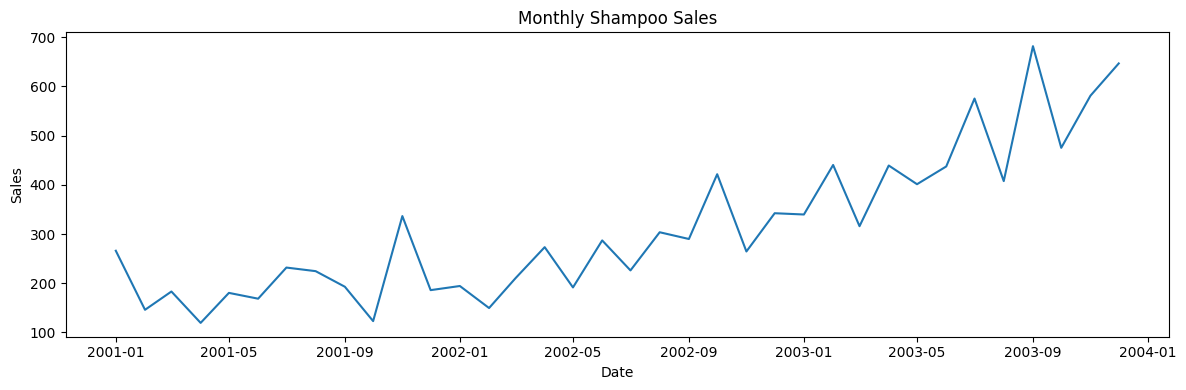

(36, 1)


,sales
2001-01-01,266.0
2001-02-01,145.9
2001-03-01,183.1
2001-04-01,119.3
2001-05-01,180.3


In [10]:
# Load shampoo sales dataset
url2 = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/shampoo.csv"
df2 = pd.read_csv(url2, header=0)
df2.columns = ['month', 'sales']
df2.index = pd.date_range(start='2001-01', periods=len(df2), freq='MS')
df2 = df2[['sales']]

plt.figure(figsize=(12, 4))
plt.plot(df2['sales'])
plt.title('Monthly Shampoo Sales')
plt.ylabel('Sales')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

print(df2.shape)
df2.head()


### Step 2: ADF Test — Find d

ADF Test — Shampoo — original
  ADF Statistic : 3.0601
  p-value       : 1.0000
  Stationary    : False

ADF Test — Shampoo — after 1st difference
  ADF Statistic : -7.2491
  p-value       : 0.0000
  Stationary    : True



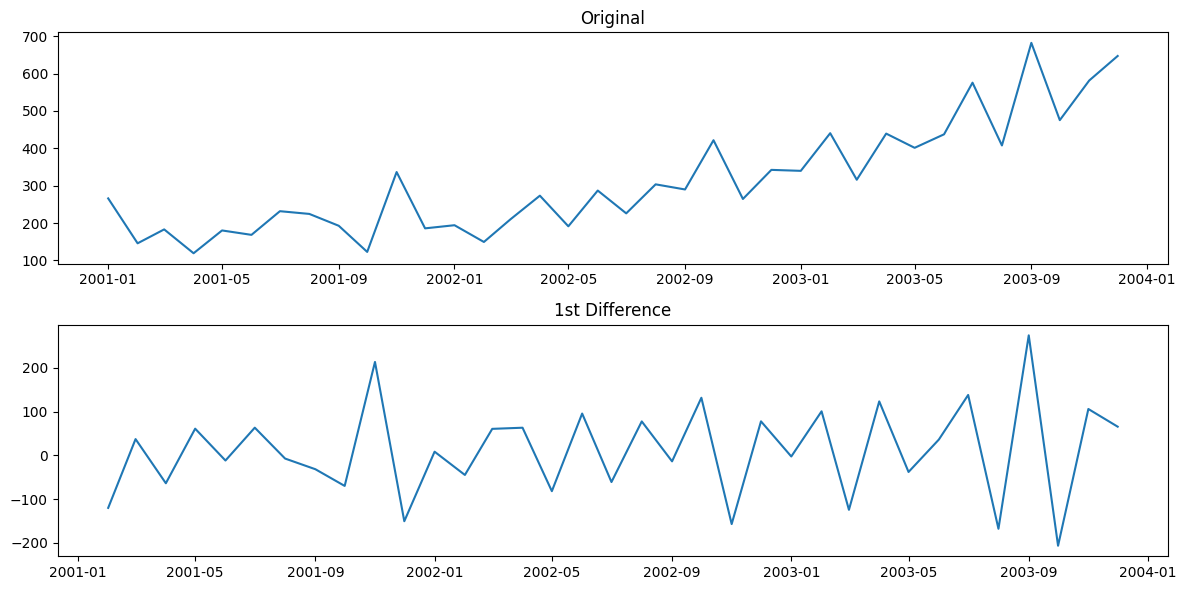

In [11]:
adf_test(df2['sales'], "Shampoo — original")

df2['diff1'] = df2['sales'].diff()
adf_test(df2['diff1'], "Shampoo — after 1st difference")

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(df2['sales']); axes[0].set_title('Original')
axes[1].plot(df2['diff1']); axes[1].set_title('1st Difference')
plt.tight_layout()
plt.show()


### Step 3: ACF and PACF — Find p and q\nNotice: no spikes at lag 12, 24 — confirms no seasonality.

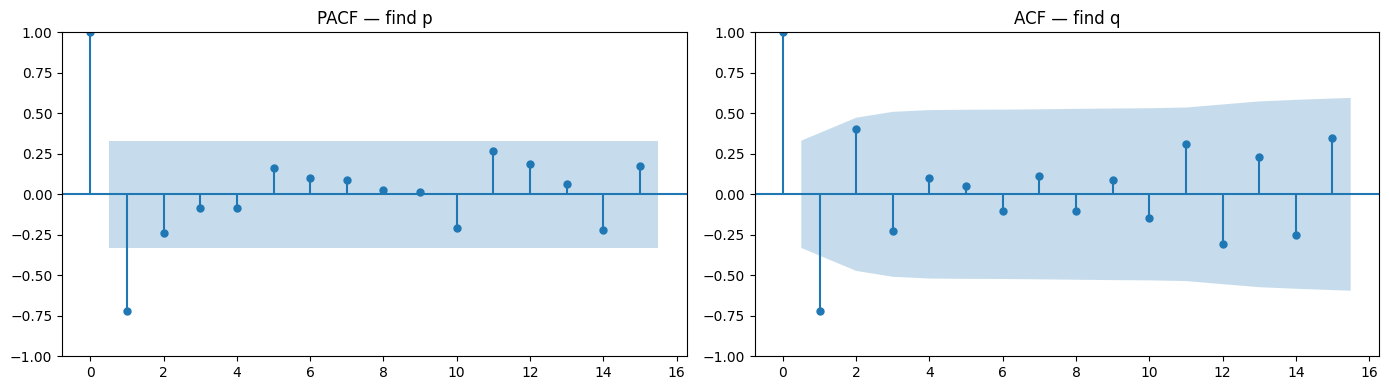

In [12]:
stationary_shampoo = df2['diff1'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_pacf(stationary_shampoo, lags=15, ax=axes[0], title='PACF — find p')
plot_acf(stationary_shampoo, lags=15, ax=axes[1], title='ACF — find q')
plt.tight_layout()
plt.show()


### Step 4: Fit ARIMA, Forecast, Evaluate\nRead the PACF/ACF plots above and update p and q before running this cell.

ARIMA(15,1,15) — RMSE: 170.55


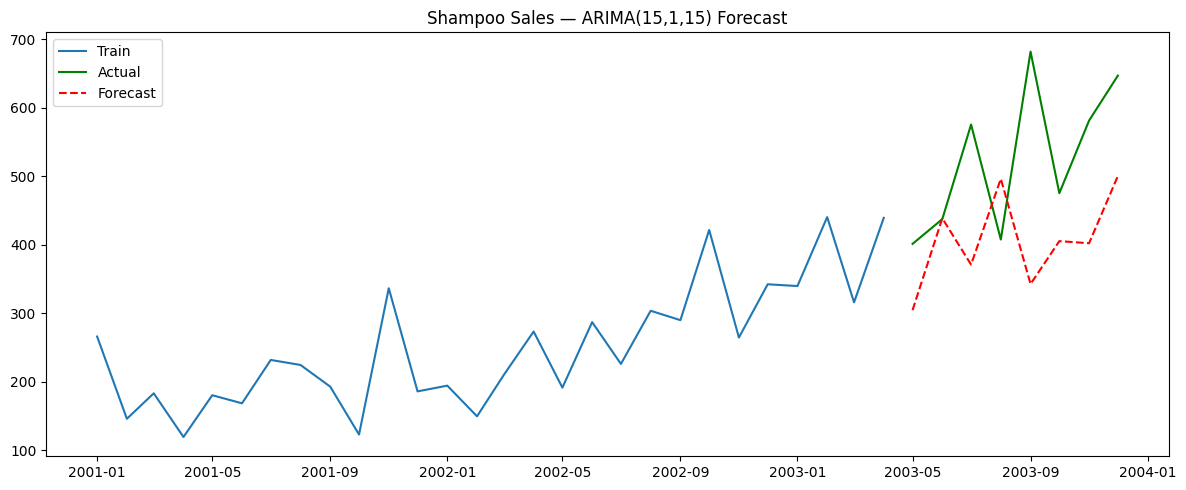

In [16]:
series2 = df2['sales']
train_size2 = int(len(series2) * 0.8)
train2, test2 = series2[:train_size2], series2[train_size2:]

# TODO: update p and q after inspecting PACF/ACF plots above
p, d, q = 15, 1, 15

model2 = ARIMA(train2, order=(p, d, q))
result2 = model2.fit()

forecast2 = result2.forecast(steps=len(test2))
rmse2 = np.sqrt(mean_squared_error(test2, forecast2))
print(f"ARIMA({p},{d},{q}) — RMSE: {rmse2:.2f}")

plt.figure(figsize=(12, 5))
plt.plot(train2, label='Train')
plt.plot(test2, label='Actual', color='green')
plt.plot(forecast2, label='Forecast', color='red', linestyle='--')
plt.title(f'Shampoo Sales — ARIMA({p},{d},{q}) Forecast')
plt.legend()
plt.tight_layout()
plt.show()


### Step 5: Residual Analysis

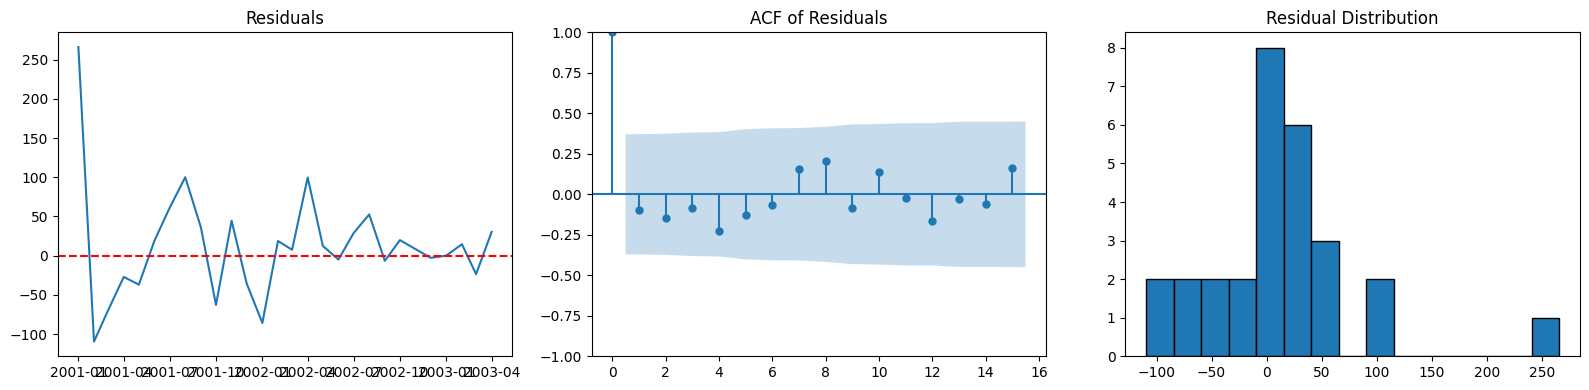

ADF Test — Shampoo residuals
  ADF Statistic : -7.8674
  p-value       : 0.0000
  Stationary    : True



In [17]:
residuals2 = result2.resid

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(residuals2); axes[0].set_title('Residuals'); axes[0].axhline(0, color='red', linestyle='--')
plot_acf(residuals2, lags=15, ax=axes[1], title='ACF of Residuals')
axes[2].hist(residuals2, bins=15, edgecolor='black'); axes[2].set_title('Residual Distribution')
plt.tight_layout()
plt.show()

adf_test(residuals2, "Shampoo residuals")


# ARIMA — Step by Step
